## CloudWatch Dashboard Setup

In [3]:
# Import Libraries
import boto3
import json
import pandas as pd
import matplotlib.pyplot as plt
from sagemaker import Session
from datetime import datetime, timedelta
from io import BytesIO

In [4]:
# Setup
session = Session()
region = session.boto_region_name
bucket = 'sagemaker-us-east-1-226675648827'
prefix = "cardio_data"

# AWS Clients
s3 = boto3.client('s3', region_name=region)
cloudwatch = boto3.client('cloudwatch', region_name=region)
sagemaker_client = boto3.client('sagemaker', region_name=region)

In [16]:
# Endpoints
log_endpoint = 'cardio-logistic-monitor-endpoint'
rf_endpoint = 'cardio-rf-monitor-endpoint'
variant_name = 'AllTraffic'

<b> Convert Categorial Columns to Numerical for Cloudwatch </b>

In [6]:
# Set up variables
file_key = f"{prefix}/cardio_prod_split40.csv"
num_file = "cardio_prod_split40_num.csv"
mapping_file = "cardio_column_mapping.json"

# Read from S3
s3 = boto3.client("s3")
response = s3.get_object(Bucket=bucket, Key=file_key)
df = pd.read_csv(response["Body"])

# Drop the target column
df_no_label = df.drop(columns=["cardio"])

# Convert headers to numerical
column_mapping = {i: col for i, col in enumerate(df_no_label.columns)}
df_no_label.columns = [str(i) for i in range(len(df_no_label.columns))]

# Save new files locally
df_no_label.to_csv(num_file, index=False)
with open(mapping_file, 'w') as f:
    json.dump(column_mapping, f, indent=4)

# Upload both files to S3
s3.upload_file(num_file, bucket, f"{prefix}/{num_file}")
s3.upload_file(mapping_file, bucket, f"{prefix}/{mapping_file}")

print("Numerical dataset and column mapping uploaded to S3.")
print(f"CSV path: s3://{bucket}/{prefix}/{num_file}")
print(f"Mapping path: s3://{bucket}/{prefix}/{mapping_file}")

Numerical dataset and column mapping uploaded to S3.
CSV path: s3://sagemaker-us-east-1-226675648827/cardio_data/cardio_prod_split40_num.csv
Mapping path: s3://sagemaker-us-east-1-226675648827/cardio_data/cardio_column_mapping.json


In [8]:
# Check Endpoint and Monitoring Schedule Status
endpoints = ['cardio-logistic-monitor-endpoint', 'cardio-rf-monitor-endpoint']
schedules = ['cardio-logistic-monitor-schedule', 'cardio-rf-monitor-schedule']

for ep in endpoints:
    status = sagemaker_client.describe_endpoint(EndpointName=ep)['EndpointStatus']
    print(f"Endpoint '{ep}' is currently: {status}")

for sched in schedules:
    sched_status = sagemaker_client.describe_monitoring_schedule(MonitoringScheduleName=sched)['MonitoringScheduleStatus']
    print(f"Monitoring Schedule '{sched}' status: {sched_status}")

Endpoint 'cardio-logistic-monitor-endpoint' is currently: InService
Endpoint 'cardio-rf-monitor-endpoint' is currently: InService
Monitoring Schedule 'cardio-logistic-monitor-schedule' status: Scheduled
Monitoring Schedule 'cardio-rf-monitor-schedule' status: Scheduled


In [9]:
# Load and Preview CSV Files for Context
file_keys = {
    "No Header (for inference)": "cardio_prod_no_label.csv",
    "Categorical Header (for JSON baselines)": "cardio_prod_split40_cat.csv",
    "Numerical Header (for CloudWatch)": "cardio_prod_split40_num.csv"
}

for label, file in file_keys.items():
    s3_path = f"s3://{bucket}/{prefix}/{file}"
    print(f"\n📁 {label} - {s3_path}")
    
    # Read and preview first 5 rows
    df = pd.read_csv(f"s3://{bucket}/{prefix}/{file}", header=None if 'No Header' in label else 'infer')
    display(df.head())


📁 No Header (for inference) - s3://sagemaker-us-east-1-226675648827/cardio_data/cardio_prod_no_label.csv


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,-0.860483,-0.323580,-0.914107,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,0.494625,...,-0.323580,-0.860483,-0.607947,-0.543807,-0.596864,0.0,2.0,0.0,1.0,1.0
1,-0.268438,1.211180,0.266123,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,-2.021734,...,1.211180,-0.268438,-0.607947,-0.422052,1.161966,1.0,2.0,2.0,2.0,1.0
2,0.915651,-1.052592,-0.983384,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,0.494625,...,-1.052592,0.915651,-0.607947,-0.178543,-0.596864,0.0,2.0,0.0,2.0,1.0
3,-0.712472,-0.822378,-1.191845,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,0.494625,...,-0.822378,-0.712472,-0.607947,-0.513368,-0.596864,0.0,2.0,0.0,1.0,1.0
4,0.323606,-0.170104,-0.358631,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,0.494625,...,-0.170104,0.323606,-0.607947,-0.300298,-0.596864,0.0,2.0,2.0,2.0,1.0



📁 Categorical Header (for JSON baselines) - s3://sagemaker-us-east-1-226675648827/cardio_data/cardio_prod_split40_cat.csv


,age,height_ft,weight_lbs,systolic_bp,diastolic_bp,cholesterol,gluc,smoke,alco,active,...,height_in,age_years,is_hypertensive,age_gluc_interaction,lifestyle_score,gender,bp_category,bmi_category,age_group,cholesterol_label
0,-0.860483,-0.323580,-0.914107,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,0.494625,...,-0.323580,-0.860483,-0.607947,-0.543807,-0.596864,0.0,2.0,0.0,1.0,1.0
1,-0.268438,1.211180,0.266123,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,-2.021734,...,1.211180,-0.268438,-0.607947,-0.422052,1.161966,1.0,2.0,2.0,2.0,1.0
2,0.915651,-1.052592,-0.983384,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,0.494625,...,-1.052592,0.915651,-0.607947,-0.178543,-0.596864,0.0,2.0,0.0,2.0,1.0
3,-0.712472,-0.822378,-1.191845,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,0.494625,...,-0.822378,-0.712472,-0.607947,-0.513368,-0.596864,0.0,2.0,0.0,1.0,1.0
4,0.323606,-0.170104,-0.358631,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,0.494625,...,-0.170104,0.323606,-0.607947,-0.300298,-0.596864,0.0,2.0,2.0,2.0,1.0



📁 Numerical Header (for CloudWatch) - s3://sagemaker-us-east-1-226675648827/cardio_data/cardio_prod_split40_num.csv


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,-0.860483,-0.323580,-0.914107,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,0.494625,...,-0.323580,-0.860483,-0.607947,-0.543807,-0.596864,0.0,2.0,0.0,1.0,1.0
1,-0.268438,1.211180,0.266123,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,-2.021734,...,1.211180,-0.268438,-0.607947,-0.422052,1.161966,1.0,2.0,2.0,2.0,1.0
2,0.915651,-1.052592,-0.983384,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,0.494625,...,-1.052592,0.915651,-0.607947,-0.178543,-0.596864,0.0,2.0,0.0,2.0,1.0
3,-0.712472,-0.822378,-1.191845,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,0.494625,...,-0.822378,-0.712472,-0.607947,-0.513368,-0.596864,0.0,2.0,0.0,1.0,1.0
4,0.323606,-0.170104,-0.358631,-0.410657,-0.147087,-0.538657,-0.390761,-0.312731,-0.23822,0.494625,...,-0.170104,0.323606,-0.607947,-0.300298,-0.596864,0.0,2.0,2.0,2.0,1.0


### Dataset Overview for Monitoring & Inference

| **Filename**                        | **Header Type**      | **Purpose**                                      |
|------------------------------------|-----------------------|--------------------------------------------------|
| `cardio_prod_no_label.csv`         | No headers         | Used for **inference** only (minimal payloads)   |
| `cardio_prod_split40_cat.csv`      | Categorical names | Used for **baseline generation** (Clarify JSONs) |
| `cardio_prod_split40_num.csv`      | Numerical headers  | Used for **CloudWatch monitoring reports**       |

### `no_label` vs `num` — What’s the Difference?

Both contain the **same data values**, but serve different roles:

- `no_label` has **no headers** – it's optimized for SageMaker model **inference input**.
- `num` has **numbered headers** – required for mapping metrics in **CloudWatch data reports**.

### Create CloudWatch Dashboard

<b> Invoke an endpoint for both models </b>

In [13]:
# Load test data (numerical version without labels)
df = pd.read_csv('cardio_prod_split40_num.csv')
payloads = df.sample(n=20).astype(float).values.tolist()  # Sample 20 rows

# SageMaker runtime client
runtime = boto3.client('sagemaker-runtime', region_name=region)

# Function to invoke an endpoint
def invoke_endpoint(endpoint_name, payloads):
    for row in payloads:
        response = runtime.invoke_endpoint(
            EndpointName=endpoint_name,
            ContentType='text/csv',
            Body=",".join(map(str, row))
        )
        print(f"{endpoint_name} response: {response['ResponseMetadata']['HTTPStatusCode']}")

# Send traffic
invoke_endpoint('cardio-logistic-monitor-endpoint', payloads)
invoke_endpoint('cardio-rf-monitor-endpoint', payloads)

cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-logistic-monitor-endpoint response: 200
cardio-rf-monitor-endpoint response: 200
cardio-rf-monitor-e

In [17]:
# CloudWatch Dashboard name
dashboard_name = 'CardioMonitoringDashboard'

In [18]:
dashboard_body = {
    "widgets": [
        # Logistic Regression - Invocation & Error Metrics
        {
            "type": "metric",
            "x": 0, "y": 0, "width": 12, "height": 6,
            "properties": {
                "metrics": [
                    ["AWS/SageMaker", "Invocations", "EndpointName", log_endpoint, "VariantName", variant_name],
                    ["AWS/SageMaker", "Invocation4XXErrors", "EndpointName", log_endpoint, "VariantName", variant_name],
                    ["AWS/SageMaker", "Invocation5XXErrors", "EndpointName", log_endpoint, "VariantName", variant_name],
                    ["AWS/SageMaker", "InvocationModelErrors", "EndpointName", log_endpoint, "VariantName", variant_name]
                ],
                "view": "timeSeries",
                "stacked": False,
                "region": region,
                "title": "Logistic Model - Invocations & Errors"
            }
        },
        # Logistic Regression - Latency
        {
            "type": "metric",
            "x": 0, "y": 6, "width": 12, "height": 6,
            "properties": {
                "metrics": [
                    ["AWS/SageMaker", "ModelLatency", "EndpointName", log_endpoint, "VariantName", variant_name]
                ],
                "view": "timeSeries",
                "region": region,
                "title": "Logistic Model - Latency (ms)"
            }
        },
        # Logistic Regression - Resource Utilization
        {
            "type": "metric",
            "x": 0, "y": 12, "width": 12, "height": 6,
            "properties": {
                "metrics": [
                    ["AWS/SageMaker", "CPUUtilization", "EndpointName", log_endpoint, "VariantName", variant_name],
                    ["AWS/SageMaker", "MemoryUtilization", "EndpointName", log_endpoint, "VariantName", variant_name]
                ],
                "view": "timeSeries",
                "region": region,
                "title": "Logistic Model - Resource Utilization"
            }
        },
        # Random Forest - Invocation & Error Metrics
        {
            "type": "metric",
            "x": 12, "y": 0, "width": 12, "height": 6,
            "properties": {
                "metrics": [
                    ["AWS/SageMaker", "Invocations", "EndpointName", rf_endpoint, "VariantName", variant_name],
                    ["AWS/SageMaker", "Invocation4XXErrors", "EndpointName", rf_endpoint, "VariantName", variant_name],
                    ["AWS/SageMaker", "Invocation5XXErrors", "EndpointName", rf_endpoint, "VariantName", variant_name],
                    ["AWS/SageMaker", "InvocationModelErrors", "EndpointName", rf_endpoint, "VariantName", variant_name]
                ],
                "view": "timeSeries",
                "stacked": False,
                "region": region,
                "title": "Random Forest - Invocations & Errors"
            }
        },
        # Random Forest - Latency
        {
            "type": "metric",
            "x": 12, "y": 6, "width": 12, "height": 6,
            "properties": {
                "metrics": [
                    ["AWS/SageMaker", "ModelLatency", "EndpointName", rf_endpoint, "VariantName", variant_name]
                ],
                "view": "timeSeries",
                "region": region,
                "title": "Random Forest - Latency (ms)"
            }
        },
        # Random Forest - Resource Utilization
        {
            "type": "metric",
            "x": 12, "y": 12, "width": 12, "height": 6,
            "properties": {
                "metrics": [
                    ["AWS/SageMaker", "CPUUtilization", "EndpointName", rf_endpoint, "VariantName", variant_name],
                    ["AWS/SageMaker", "MemoryUtilization", "EndpointName", rf_endpoint, "VariantName", variant_name]
                ],
                "view": "timeSeries",
                "region": region,
                "title": "Random Forest - Resource Utilization"
            }
        }
    ]
}

# Push the updated dashboard
cloudwatch.put_dashboard(
    DashboardName=dashboard_name,
    DashboardBody=json.dumps(dashboard_body)
)

print(f"CloudWatch Dashboard '{dashboard_name}.")

CloudWatch Dashboard 'CardioMonitoringDashboard.


### Activate CloudWatch Alarm

In [19]:
# Initialize CloudWatch client
cloudwatch = boto3.client('cloudwatch', region_name='us-east-1')

# Define alarm configurations for each endpoint
endpoints = ['cardio-logistic-monitor-endpoint', 'cardio-rf-monitor-endpoint']
metrics = ['Invocation4XXErrors', 'Invocation5XXErrors', 'InvocationModelErrors']
alarms = []

for endpoint in endpoints:
    for metric in metrics:
        alarm_name = f"{endpoint}-{metric}-Alarm"
        response = cloudwatch.put_metric_alarm(
            AlarmName=alarm_name,
            MetricName=metric,
            Namespace='AWS/SageMaker',
            Statistic='Sum',
            Period=300,
            EvaluationPeriods=1,
            Threshold=1,
            ComparisonOperator='GreaterThanOrEqualToThreshold',
            Dimensions=[
                {'Name': 'EndpointName', 'Value': endpoint},
                {'Name': 'VariantName', 'Value': 'AllTraffic'}
            ],
            AlarmDescription=f"Alarm when {metric} >= 1 for {endpoint}",
            ActionsEnabled=False  # You can link SNS later
        )
        alarms.append(alarm_name)

alarms

['cardio-logistic-monitor-endpoint-Invocation4XXErrors-Alarm',
 'cardio-logistic-monitor-endpoint-Invocation5XXErrors-Alarm',
 'cardio-logistic-monitor-endpoint-InvocationModelErrors-Alarm',
 'cardio-rf-monitor-endpoint-Invocation4XXErrors-Alarm',
 'cardio-rf-monitor-endpoint-Invocation5XXErrors-Alarm',
 'cardio-rf-monitor-endpoint-InvocationModelErrors-Alarm']

<b>Logistic Regression Endpoint (cardio-logistic-monitor-endpoint)</b><br>
<b>Random Forest Endpoint (cardio-rf-monitor-endpoint)</b>
* Invocation4XXErrors – detects client-side issues (e.g., bad input)
* Invocation5XXErrors – detects server-side failures
* InvocationModelErrors – captures errors thrown by the model itself

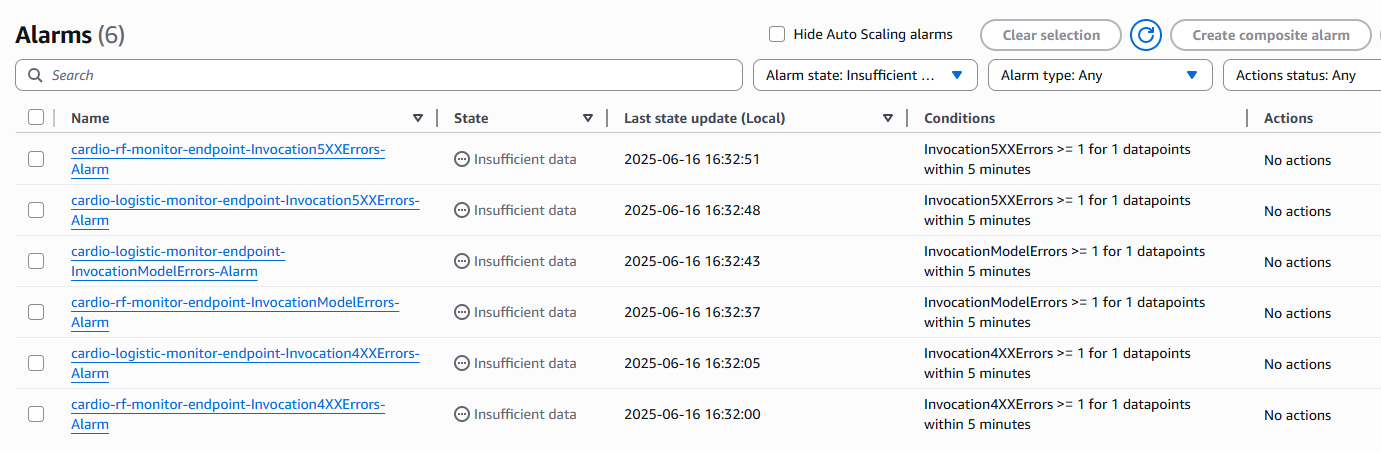

### Monitor Metrics

In [20]:
# Define monitoring metrics of interest
metrics = [
    'ModelLatency',
    'Invocation4XXErrors',
    'Invocation5XXErrors',
    'InvocationModelErrors',
    'Invocations',
    'InvocationsPerInstance',
    'CPUUtilization',
    'MemoryUtilization'
]

In [21]:
# Define function to fetch and plot metrics
def fetch_and_plot_metrics(endpoint_name):
    end_time = datetime.utcnow()
    start_time = end_time - timedelta(days=1)
    period = 3600  # 1 hour

    for metric in metrics:
        response = cloudwatch.get_metric_statistics(
            Namespace='AWS/SageMaker',
            MetricName=metric,
            Dimensions=[
                {'Name': 'EndpointName', 'Value': endpoint_name}
            ],
            StartTime=start_time,
            EndTime=end_time,
            Period=period,
            Statistics=['Average']
        )

        datapoints = response['Datapoints']
        datapoints.sort(key=lambda x: x['Timestamp'])

        if datapoints:
            timestamps = [dp['Timestamp'] for dp in datapoints]
            values = [dp['Average'] for dp in datapoints]

            plt.figure(figsize=(10, 4))
            plt.plot(timestamps, values, marker='o')
            plt.title(f"{metric} for {endpoint_name}")
            plt.xlabel("Timestamp")
            plt.ylabel(metric)
            plt.grid(True)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print(f"No data for metric '{metric}' on endpoint '{endpoint_name}'.")

# Run for both endpoints
fetch_and_plot_metrics("cardio-logistic-monitor-endpoint")
fetch_and_plot_metrics("cardio-rf-monitor-endpoint")

No data for metric 'ModelLatency' on endpoint 'cardio-logistic-monitor-endpoint'.
No data for metric 'Invocation4XXErrors' on endpoint 'cardio-logistic-monitor-endpoint'.
No data for metric 'Invocation5XXErrors' on endpoint 'cardio-logistic-monitor-endpoint'.
No data for metric 'InvocationModelErrors' on endpoint 'cardio-logistic-monitor-endpoint'.
No data for metric 'Invocations' on endpoint 'cardio-logistic-monitor-endpoint'.
No data for metric 'InvocationsPerInstance' on endpoint 'cardio-logistic-monitor-endpoint'.
No data for metric 'CPUUtilization' on endpoint 'cardio-logistic-monitor-endpoint'.
No data for metric 'MemoryUtilization' on endpoint 'cardio-logistic-monitor-endpoint'.
No data for metric 'ModelLatency' on endpoint 'cardio-rf-monitor-endpoint'.
No data for metric 'Invocation4XXErrors' on endpoint 'cardio-rf-monitor-endpoint'.
No data for metric 'Invocation5XXErrors' on endpoint 'cardio-rf-monitor-endpoint'.
No data for metric 'InvocationModelErrors' on endpoint 'cardio-

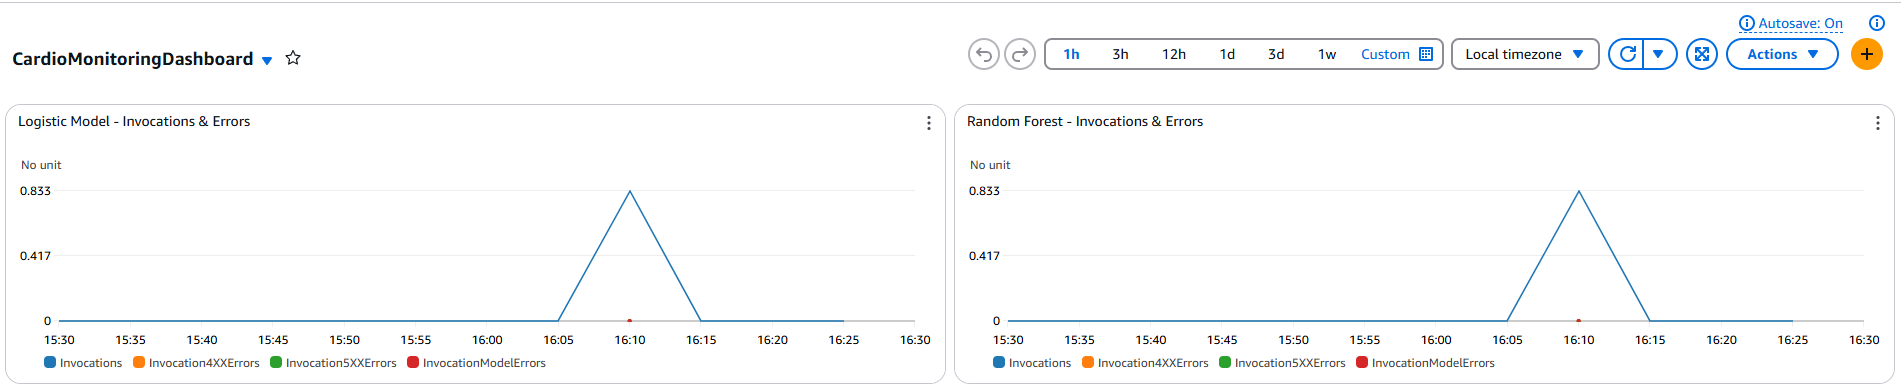

### Data Reports

In [30]:
# Baseline Contraint Reports
key = 'cardio_data/baseline-results/constraints.json'
constraints_obj = s3.get_object(Bucket=bucket, Key=key)
constraints = json.loads(constraints_obj['Body'].read().decode('utf-8'))

print("\nBaseline Constraint Violations Summary")
for feature in constraints.get("features", []):
    name = feature["name"]
    violations = feature.get("violations", [])
    if violations:
        print(f"Feature '{name}' → Violations: {violations}")
    else:
        print(f"Feature '{name}' has no violations.")


Baseline Constraint Violations Summary
Feature 'age' has no violations.
Feature 'gender' has no violations.
Feature 'height_ft' has no violations.
Feature 'weight_lbs' has no violations.
Feature 'systolic_bp' has no violations.
Feature 'diastolic_bp' has no violations.
Feature 'cholesterol' has no violations.
Feature 'gluc' has no violations.
Feature 'smoke' has no violations.
Feature 'alco' has no violations.
Feature 'active' has no violations.
Feature 'cardio' has no violations.
Feature 'bmi' has no violations.
Feature 'age_group' has no violations.
Feature 'cholesterol_label' has no violations.
Feature 'pulse_pressure' has no violations.
Feature 'chol_bmi_ratio' has no violations.
Feature 'height_in' has no violations.
Feature 'age_years' has no violations.
Feature 'is_hypertensive' has no violations.
Feature 'bp_category' has no violations.
Feature 'bmi_category' has no violations.
Feature 'age_gluc_interaction' has no violations.
Feature 'lifestyle_score' has no violations.


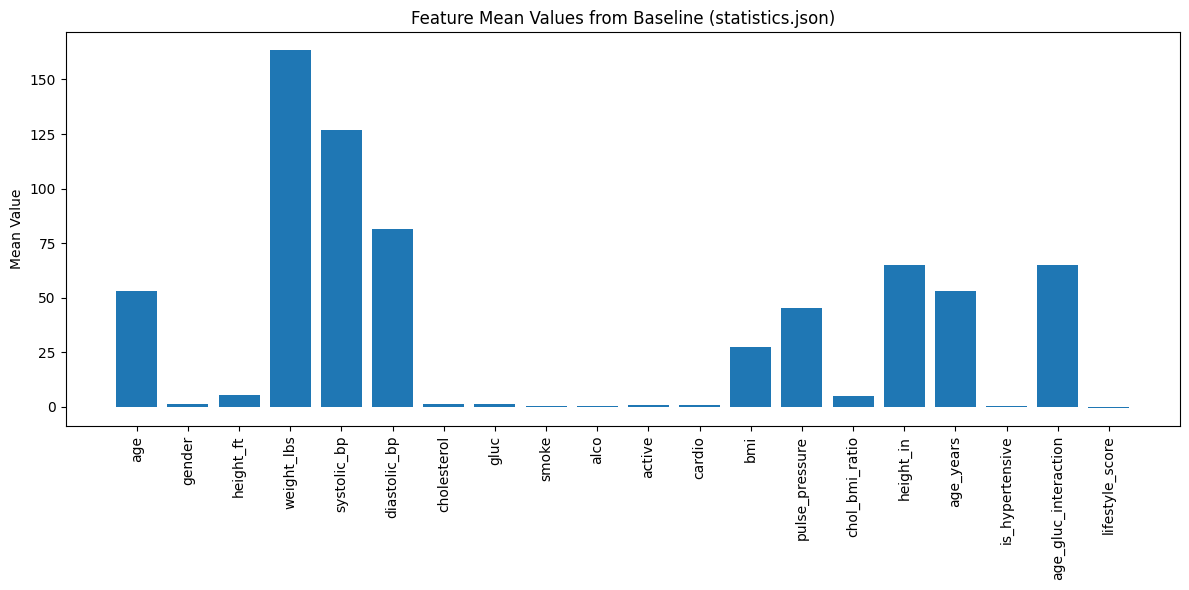

In [24]:
# Baseline Statistics Report
key = 'cardio_data/baseline-results/statistics.json'
response = s3.get_object(Bucket=bucket, Key=key)
statistics = json.loads(response['Body'].read().decode('utf-8'))

features_stats = statistics['features']
df_stats = pd.DataFrame(features_stats)
df_stats = df_stats[df_stats['numerical_statistics'].notnull()]

summary_data = []
for row in df_stats.itertuples():
    stats = row.numerical_statistics
    summary_data.append({
        'Feature': row.name,
        'Mean': stats.get('mean'),
        'Min': stats.get('min'),
        'Max': stats.get('max'),
        'StdDev': stats.get('standard_deviation')
    })

summary_df = pd.DataFrame(summary_data)
plt.figure(figsize=(12, 6))
plt.bar(summary_df['Feature'], summary_df['Mean'])
plt.xticks(rotation=90)
plt.ylabel("Mean Value")
plt.title("Feature Mean Values from Baseline (statistics.json)")
plt.tight_layout()
plt.show()

This bar chart displays the mean values of each numerical feature from the baseline statistics generated for the cardiovascular disease (CVD) prediction model. Each bar represents the average value of a clinical or lifestyle variable across the baseline dataset, such as blood pressure, cholesterol, glucose, and BMI. The visualization allows us to quickly assess central tendencies in the data, identify potential outliers, and confirm that the dataset reflects realistic and expected distributions. For example, average systolic and diastolic blood pressure levels, cholesterol, and glucose means should align with clinical norms, ensuring that the baseline data is representative of a typical patient population.

This visual supports the project's core objective of proactive CVD detection by validating the integrity and structure of the baseline data used to monitor the deployed model. If future inference data shows significant deviation from these mean values, it could signal feature drift or shifts in patient health profiles. Monitoring such trends is essential for maintaining model performance and reliability over time. By comparing incoming data distributions to this baseline, the system can trigger alerts for retraining or investigation, ensuring that clinical decisions remain informed and responsive to real-world changes. This transforms the model from a static predictor into a dynamic tool for real-time health surveillance.

In [32]:
# Confirm CloudWatch Metrics
for endpoint in [log_endpoint, rf_endpoint]:
    metrics = cloudwatch.list_metrics(
        Namespace='AWS/SageMaker',
        Dimensions=[{'Name': 'EndpointName', 'Value': endpoint}]
    )
    print(f"\nMetrics for: {endpoint}")
    for metric in metrics['Metrics']:
        print(f"- {metric['MetricName']}")


Metrics for: cardio-logistic-monitor-endpoint
- Invocations
- InvocationsPerInstance
- ConcurrentRequestsPerModel
- Invocation4XXErrors
- ModelLatency
- Invocation4XXErrors
- InvocationModelErrors
- InvocationModelErrors
- Invocation5XXErrors
- Invocations
- OverheadLatency
- OverheadLatency
- InvocationsPerInstance
- Invocation5XXErrors
- ModelLatency

Metrics for: cardio-rf-monitor-endpoint
- OverheadLatency
- InvocationModelErrors
- Invocation5XXErrors
- ModelLatency
- Invocations
- InvocationsPerInstance
- Invocation5XXErrors
- OverheadLatency
- InvocationModelErrors
- Invocation4XXErrors
- Invocation4XXErrors
- ModelLatency
- ConcurrentRequestsPerModel
- InvocationsPerInstance
- Invocations


In [ ]:
# Save feature group to S3
!aws s3 cp cardio_cloudwatch_and_data_reports.ipynb s3://sagemaker-us-east-1-226675648827/monitoring/cardio_cloudwatch_and_data_reports.ipynb